In [1]:
import numpy as np
import matplotlib.pyplot as plt
from codes.Quantum import *
from codes.CSPSA import *

In [2]:
psi = np.array([1, 0 , 0, 0, 0, 0, 0 , 1])/np.sqrt(2)
rho = np.outer( psi, psi.conj() )
rho 

array([[0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0.5],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0.5]])

In [3]:
def postprocessing( x ):
    x = x/np.linalg.norm(x, axis=0 )
    return x 

def obj_fun( x ):

    x = postprocessing( x )

    obs = []

    for j in range(6): 
        obs.append( vector2observable( x[:,j] ) ) # obs.shape = (6,2,2)

    obs = np.array( obs ).reshape( 3, 2, 2, 2 ) # qubit_label, obs_label, matrix_row, matrix_col 

    # Bell = np.real( np.trace( rho@triple_kron( obs[0,1], obs[1,0], obs[2,0] ) ) 
    #         + np.trace( rho@triple_kron( obs[0,0], obs[1,1], obs[2,0] ) ) 
    #         + np.trace( rho@triple_kron( obs[0,0], obs[1,0], obs[2,1] ) ) 
    #         - np.trace( rho@triple_kron( obs[0,1], obs[1,1], obs[2,1] ) ) 
    #         - np.trace( rho@triple_kron( obs[0,0], obs[1,1], obs[2,1] ) ) 
    #         - np.trace( rho@triple_kron( obs[0,1], obs[1,0], obs[2,1] ) ) 
    #         - np.trace( rho@triple_kron( obs[0,1], obs[1,1], obs[2,0] ) ) 
    #         + np.trace( rho@triple_kron( obs[0,0], obs[1,0], obs[2,0] ) ) 
    #         )
    
    Bell = np.real( InnerProductMatrices( rho, [obs[0,1], obs[1,0], obs[2,0]] ) 
                    + InnerProductMatrices( rho, [obs[0,0], obs[1,1], obs[2,0]] )
                    + InnerProductMatrices( rho, [obs[0,0], obs[1,0], obs[2,1]] )
                    - InnerProductMatrices( rho, [obs[0,1], obs[1,1], obs[2,1]] )
                    - InnerProductMatrices( rho, [obs[0,0], obs[1,1], obs[2,1]] )
                    - InnerProductMatrices( rho, [obs[0,1], obs[1,0], obs[2,1]] )
                    - InnerProductMatrices( rho, [obs[0,1], obs[1,1], obs[2,0]] )              
                    + InnerProductMatrices( rho, [obs[0,0], obs[1,0], obs[2,0]] )
                    )

    return Bell 

In [4]:
gains = [ 0.2, 0, 0.2, 0.602, 0.101]
cspsa = CSPSA(gains=gains, minimize=False )
max_iter = 100

z_in = np.array( [ RandomState(2) for _ in range(6) ] ).T
z_in.shape  

(2, 6)

In [5]:
results = cspsa.minimize( obj_fun, 
                         z_in, 
                         max_iter, 
                         postprocessing=postprocessing )
#187ms / 124ms

array([5.65136816])

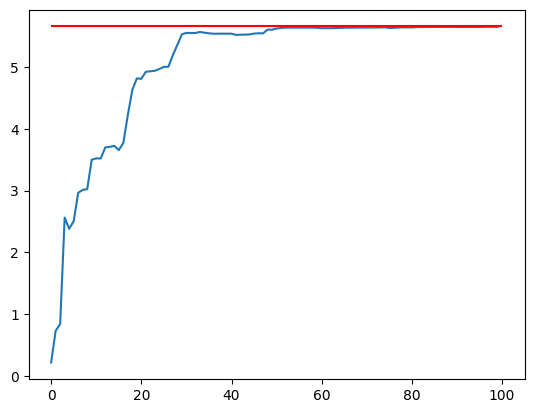

In [6]:
bell = results.fun
plt.plot( bell )
plt.hlines( 4*np.sqrt(2), 0, max_iter, 'r' )
bell[-1]